Validation: Image accepted
Detecting paper...
Normalizing background...
Enhancing colors...
Removing noise...
Cropping to content...
Resizing...
✓ Complete!


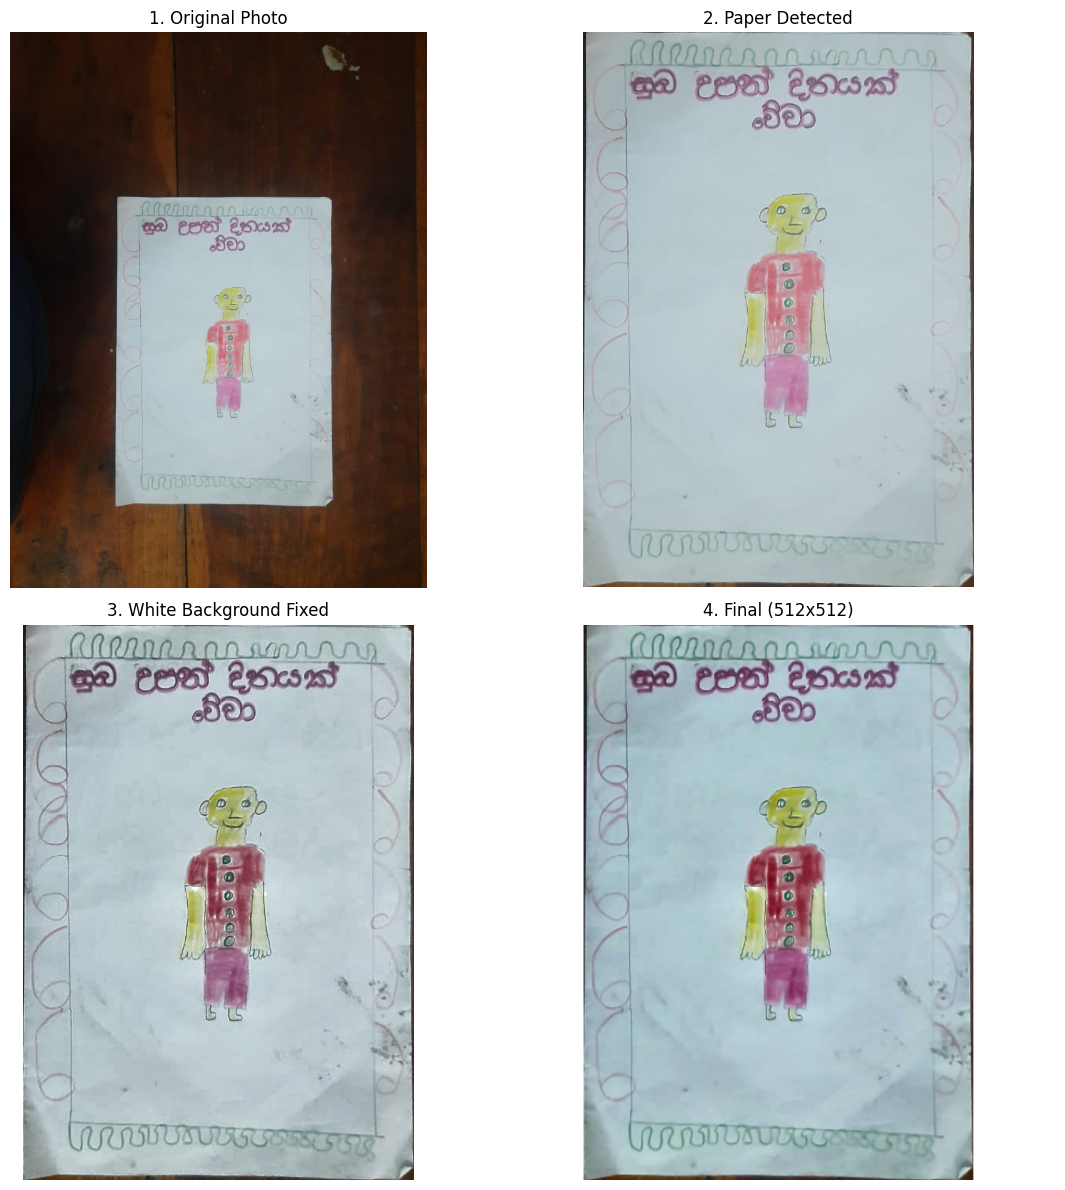


✓ Saved to /content/processed_drawing.png


In [2]:
# -*- coding: utf-8 -*-
"""
Fixed pipeline - keeps your original paper detection, properly preserves white paper
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap=None):
    plt.figure(figsize=(6,6))
    plt.imshow(img if cmap is None else img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

def validate_image(img):
    """Your original validation - it was good"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    if h < 400 or w < 400:
        return False, "Image resolution too low"

    mean_brightness = np.mean(gray)
    if mean_brightness < 60 or mean_brightness > 200:
        return False, "Lighting conditions not suitable"

    contrast = gray.std()
    if contrast < 25:
        return False, "Low contrast image"

    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size
    if edge_density > 0.15:
        return False, "Background too complex"

    return True, "Image accepted"

def detect_and_crop_paper(img):
    """
    YOUR ORIGINAL - This was actually working well!
    Detects white paper as the brightest large region
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Paper is the brightest large region
    thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        51, -5
    )

    kernel = np.ones((7,7), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)

    # Sanity check: paper must be large
    if cv2.contourArea(largest) < 0.25 * img.shape[0] * img.shape[1]:
        return None

    x, y, w, h = cv2.boundingRect(largest)
    return img[y:y+h, x:x+w]

def normalize_white_background(img):
    """
    Make paper pure white WITHOUT turning it black
    Only brighten the paper, keep drawing colors intact
    """
    # Convert to LAB
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # Normalize lighting gently
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    # Merge back
    lab_normalized = cv2.merge((l, a, b))
    normalized = cv2.cvtColor(lab_normalized, cv2.COLOR_LAB2RGB)

    # Find paper regions (very bright areas)
    gray = cv2.cvtColor(normalized, cv2.COLOR_RGB2GRAY)

    # Key fix: Use high threshold to only select PAPER, not drawing
    _, paper_mask = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY)

    # Small morphology to clean mask
    kernel = np.ones((3,3), np.uint8)
    paper_mask = cv2.morphologyEx(paper_mask, cv2.MORPH_OPEN, kernel)

    # Make ONLY paper regions pure white, leave drawing alone
    result = normalized.copy()
    result[paper_mask == 255] = [255, 255, 255]

    return result

def enhance_colors(img):
    """
    Boost crayon colors to match dataset vibrancy
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    # Boost saturation only where there's actual color
    s_enhanced = np.clip(s.astype(float) * 1.25 + 10, 0, 255).astype(np.uint8)

    # Merge back
    enhanced_hsv = cv2.merge((h, s_enhanced, v))
    result = cv2.cvtColor(enhanced_hsv, cv2.COLOR_HSV2RGB)

    return result

def remove_noise(img):
    """
    Remove camera noise while preserving crayon texture
    """
    # Very gentle bilateral filter
    result = cv2.bilateralFilter(img, 5, 50, 50)
    return result

def crop_to_content(img):
    """
    Remove excess white borders around the drawing
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Find non-white pixels
    _, mask = cv2.threshold(gray, 250, 255, cv2.THRESH_BINARY_INV)

    coords = cv2.findNonZero(mask)
    if coords is None:
        return img

    x, y, w, h = cv2.boundingRect(coords)

    # Add 5% padding
    pad_x = max(5, int(w * 0.05))
    pad_y = max(5, int(h * 0.05))

    x = max(0, x - pad_x)
    y = max(0, y - pad_y)
    w = min(img.shape[1] - x, w + 2 * pad_x)
    h = min(img.shape[0] - y, h + 2 * pad_y)

    return img[y:y+h, x:x+w]

def resize_to_standard(img, target_size=512):
    """
    Resize to dataset format with white padding
    """
    h, w = img.shape[:2]

    scale = min(target_size / w, target_size / h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # WHITE canvas
    canvas = np.full((target_size, target_size, 3), 255, dtype=np.uint8)

    y_offset = (target_size - new_h) // 2
    x_offset = (target_size - new_w) // 2
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    return canvas

def full_pipeline(image_path, target_size=512):
    """
    Clean pipeline:
    1. Validate
    2. Detect paper (YOUR original method)
    3. Normalize white background (FIXED - no more black paper!)
    4. Enhance colors
    5. Remove noise
    6. Crop and resize
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Cannot read {image_path}")
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Validate
    valid, msg = validate_image(img)
    print(f"Validation: {msg}")
    if not valid:
        return None

    # Detect paper using YOUR original method
    print("Detecting paper...")
    paper = detect_and_crop_paper(img)
    if paper is None:
        print("Paper detection failed")
        return None

    # Process the drawing
    print("Normalizing background...")
    normalized = normalize_white_background(paper)

    print("Enhancing colors...")
    enhanced = enhance_colors(normalized)

    print("Removing noise...")
    denoised = remove_noise(enhanced)

    print("Cropping to content...")
    cropped = crop_to_content(denoised)

    print("Resizing...")
    final = resize_to_standard(cropped, target_size)

    print("✓ Complete!")
    return img, paper, normalized, final

# Usage
if __name__ == "__main__":
    result = full_pipeline("wood bg1.jpeg", target_size=512)

    if result:
        original, paper, normalized, final = result

        fig, axes = plt.subplots(2, 2, figsize=(12, 12))

        axes[0, 0].imshow(original)
        axes[0, 0].set_title("1. Original Photo")
        axes[0, 0].axis("off")

        axes[0, 1].imshow(paper)
        axes[0, 1].set_title("2. Paper Detected")
        axes[0, 1].axis("off")

        axes[1, 0].imshow(normalized)
        axes[1, 0].set_title("3. White Background Fixed")
        axes[1, 0].axis("off")

        axes[1, 1].imshow(final)
        axes[1, 1].set_title("4. Final (512x512)")
        axes[1, 1].axis("off")

        plt.tight_layout()
        plt.show()

        # Save
        final_bgr = cv2.cvtColor(final, cv2.COLOR_RGB2BGR)
        cv2.imwrite("/content/processed_drawing.png", final_bgr)
        print("\n✓ Saved to /content/processed_drawing.png")
    else:
        print("\nPipeline failed!")